<a href="https://colab.research.google.com/github/MdMostafizurRahaman/Machine-Learning/blob/main/Exercise-1/linear-regression-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚘 💵 HW4 Lab: Used cars and linear regression

<img src="https://github.com/joshuagrossman/mse125-labs-public/blob/main/hw4/img/cars.jpeg?raw=1" alt= “cars” width="500" />

## ✅ Setup and data import
In this lab, we'll explore correlation, simple regression, multiple regression, and confidence intervals with used car data from [Edmunds.com](https://edmunds.com). Our goal will be to predict the price of used cars using the features of each car.

In [2]:
# Load in additional functions
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use three digits past the decimal point
# Don't use scientific notation
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Format plots with a white background and dark features.
sns.set_style('whitegrid')

# Increase the default text size of plots.
# If you are *not* working in Google Colab, we recommend commenting
# out this line of code.
plt.rcParams['font.size'] = 20

# Increase the default plot width and height.
# If you are *not* working in Google Colab, we recommend commenting
# out this line of code.
plt.rcParams['figure.figsize'] = (12, 8)

cars = pd.read_csv("https://jdgrossman.com/assets/used-cars.tsv", sep='\t')

# peek at 10 random rows
cars.sample(10)

,type,year,make,model,trim,mileage,price
1063,USED,2012,Lexus,RX 350,Base,25864,35988
474,USED,2011,BMW,3 Series,335i xDrive,49735,30000
305,USED,2012,Audi,A4,2.0T Premium,50085,24999
955,USED,2011,Infiniti,G Sedan,G25x,20105,22998
1147,USED,2012,Lexus,RX 350,Base,31883,34980
1152,USED,2009,Lexus,RX 350,Base,52732,21900
309,USED,2012,Audi,A4,2.0T Premium quattro,14534,27500
1077,USED,2012,Lexus,RX 350,Base,47059,36988
1081,USED,2012,Lexus,RX 350,Base,22176,38988
38,USED,2012,Acura,TL,Base,36617,23991


## 🚀 Exercise 1

Create a new dataset called `accords`. The dataset should only include rows corresponding to used Honda Accords.

Using the `accords` data and the `lm` function, fit the following linear regression model:

$$ y_{\text{price,}i} = \beta_0 + \beta_1 x_{\text{mileage},i} + \epsilon_i, $$

where $\epsilon_i \sim N(0, \sigma^2)$.

Print your regression output with the `summary` function. Using your output, identify and interpret the following quantities in no more than one sentence each:

- $\hat{\beta}_0$
- $\hat{\beta}_1$
- $\text{se}({\hat{\beta}_0})$,
- $\text{se}({\hat{\beta}_1})$,
- $\hat{\sigma}$
- $\text{R}^2$

Note: You should not report more precision than is necessary. For example, if your model returns a coefficient of 1.123456, it's sufficient (and desirable) to report 1.1 or 1.12 as the coefficient.

In [16]:
# Create accords dataset: filter for Honda Accords
accords = cars[(cars['make'] == 'Honda') & (cars['model'] == 'Accord')]

# Fit linear regression model: price ~ mileage
import statsmodels.api as sm

X = accords['mileage']
y = accords['price']
X = sm.add_constant(X)  # Add intercept term

model = sm.OLS(y, X).fit()
print(model.summary())

# Print sigma (residual standard deviation)
print(f"\nSigma (residual std dev): {model.scale**0.5:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     348.9
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           2.58e-37
Time:                        10:43:46   Log-Likelihood:                -1122.7
No. Observations:                 122   AIC:                             2249.
Df Residuals:                     120   BIC:                             2255.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.068e+04    399.474     51.757      0.0

In [17]:
# Verify sigma calculation
print(f"MSE (model.scale): {model.scale}")
print(f"Sigma calculated: {model.scale**0.5}")
print(f"Manual SSE / (n-p): {sum(model.resid**2) / (len(model.resid) - 2)}")
print(f"Sqrt of that: {(sum(model.resid**2) / (len(model.resid) - 2))**0.5}")

MSE (model.scale): 5858378.410531107
Sigma calculated: 2420.4087279901937
Manual SSE / (n-p): 5858378.410531109
Sqrt of that: 2420.408727990194


---

The value of $\hat{\beta}_0$ with units: 20680 dollars

Interpretation: The predicted price of a Honda Accord with 0 miles is $20,680.

---

The value of $\hat{\beta}_1$ with units: -0.088 dollars per mile

Interpretation: For each additional mile on the odometer, the price decreases by $0.088 on average.

---

The value of $\text{se}({\hat{\beta}_0})$ with units: 399 dollars

Interpretation: The standard error of the intercept estimate is $399, indicating the uncertainty around the predicted price at 0 miles.

---

The value of $\text{se}({\hat{\beta}_1})$ with units: 0.005 dollars per mile

Interpretation: The standard error of the mileage coefficient is $0.005, showing the precision of the estimated decrease in price per mile.

---

The value of $\hat{\sigma}$ with units: 2420 dollars

Interpretation: The residual standard deviation is $2420, representing the average deviation of observed prices from the predicted prices.

---

The value of $\text{R}^2$ with units: 0.744

Interpretation: 74.4% of the variation in Honda Accord prices is explained by mileage.

---

## 🚀 Exercise 2

Using the `predict` function and the model from the previous exercise, predict the average price of a used Honda Accord with an odometer reading of 50,000 miles. Provide a normally-approximated confidence interval for this mean.

In [5]:
# Predict price for 50,000 miles
import pandas as pd

new_data = pd.DataFrame({'const': 1, 'mileage': 50000}, index=[0])
pred = model.get_prediction(new_data)
print(f"Predicted average price: ${pred.predicted_mean[0]:.0f}")
ci = pred.conf_int()
print(f"95% confidence interval: (${ci[0][0]:.0f}, ${ci[0][1]:.0f})")

Predicted average price: $16285
95% confidence interval: ($15809, $16761)


## 🚀 Exercise 3

Repeat Exercise 2 for a used Honda Accord with an odometer reading of 300,000 miles.

Using this result, can you identify a critical issue with your regression model? Answer in one or two sentences.

In [6]:
# Predict price for 300,000 miles
new_data_high = pd.DataFrame({'const': 1, 'mileage': 300000}, index=[0])
pred_high = model.get_prediction(new_data_high)
print(f"Predicted average price: ${pred_high.predicted_mean[0]:.0f}")
ci_high = pred_high.conf_int()
print(f"95% confidence interval: (${ci_high[0][0]:.0f}, ${ci_high[0][1]:.0f})")

Predicted average price: $-5667
95% confidence interval: ($-7842, $-3492)


---

The linear model predicts a negative price for high mileage (300,000 miles), which is unrealistic as car prices cannot be negative. This indicates the model is extrapolating beyond the data range and doesn't account for diminishing returns or a floor price.

---

## 🚀 Exercise 4

Graphically present your regression model from Exercise 1. Specifically, plot the data with
a scatter plot, and include a regression line with the corresponding confidence bands.

- Note that this can be achieved in R using
`geom_smooth` function from `ggplot2`.

- Make sure to adjust the limits of your plot so you can see the issue you identified in the previous problem.

- Format your plot nicely!

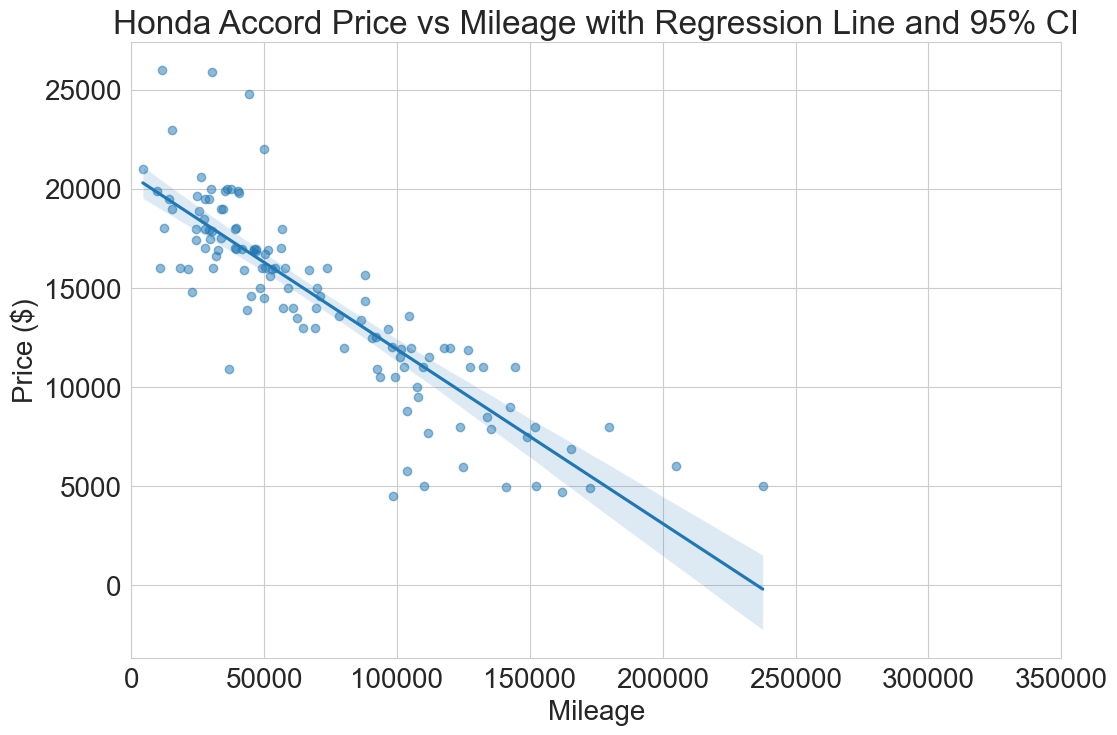

In [18]:
# Plot scatter with regression line and CI
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(data=accords, x='mileage', y='price', ci=95, scatter_kws={'alpha':0.5})
plt.title('Honda Accord Price vs Mileage with Regression Line and 95% CI')
plt.xlabel('Mileage')
plt.ylabel('Price ($)')
plt.xlim(0, 350000)  # To show the issue
plt.show()

## 🚀 Exercise 5

Address the issue illustrated in Exercises 3 and 4 by refitting your model with a log-transformed outcome.

Use your new model to predict the price (in dollars) of a Honda Accord with a mileage of 50,000 and a mileage of 300,000. **Print the new predicted prices.**

In [8]:
# Refit model with log(price)
import numpy as np

X_accords = sm.add_constant(accords['mileage'])
y_log = np.log(accords['price'])
model_log = sm.OLS(y_log, X_accords).fit()

# Predict for 50,000 miles
pred_50k = np.exp(model_log.predict(pd.DataFrame({'const': 1, 'mileage': 50000}, index=[0])))
print(f"Predicted price for 50,000 miles: ${pred_50k[0]:.0f}")

# Predict for 300,000 miles
pred_300k = np.exp(model_log.predict(pd.DataFrame({'const': 1, 'mileage': 300000}, index=[0])))
print(f"Predicted price for 300,000 miles: ${pred_300k[0]:.0f}")

Predicted price for 50,000 miles: $15746
Predicted price for 300,000 miles: $2499


## 🚀 Exercise 6

Graphically present your regression model from Exercise 5. Specifically, plot the data with
a scatter plot, and include a regression line with the corresponding confidence bands.

- Make sure to adjust the limits of your plot so you can see that the issue you identified earlier is now fixed.

- Format your plot nicely!

- Note that the new model can be plotted in R using the `geom_smooth` function with the following arguments:

`geom_smooth(method = "glm", formula = y~x, method.args = list(family = gaussian(link = 'log')))`

> Note: `geom_smooth(method='lm', formula=log(y)~x)` will also plot the correct model (with much prettier and clearer syntax!). However, it puts the model on a logarithmic y-scale instead of a standard numeric scale.
>
> Alternatively, you could use `geom_line()` with a dataset consisting of many possible mileage values (e.g., 0 through 350,000) along with the corresponding predictions  from your new model.

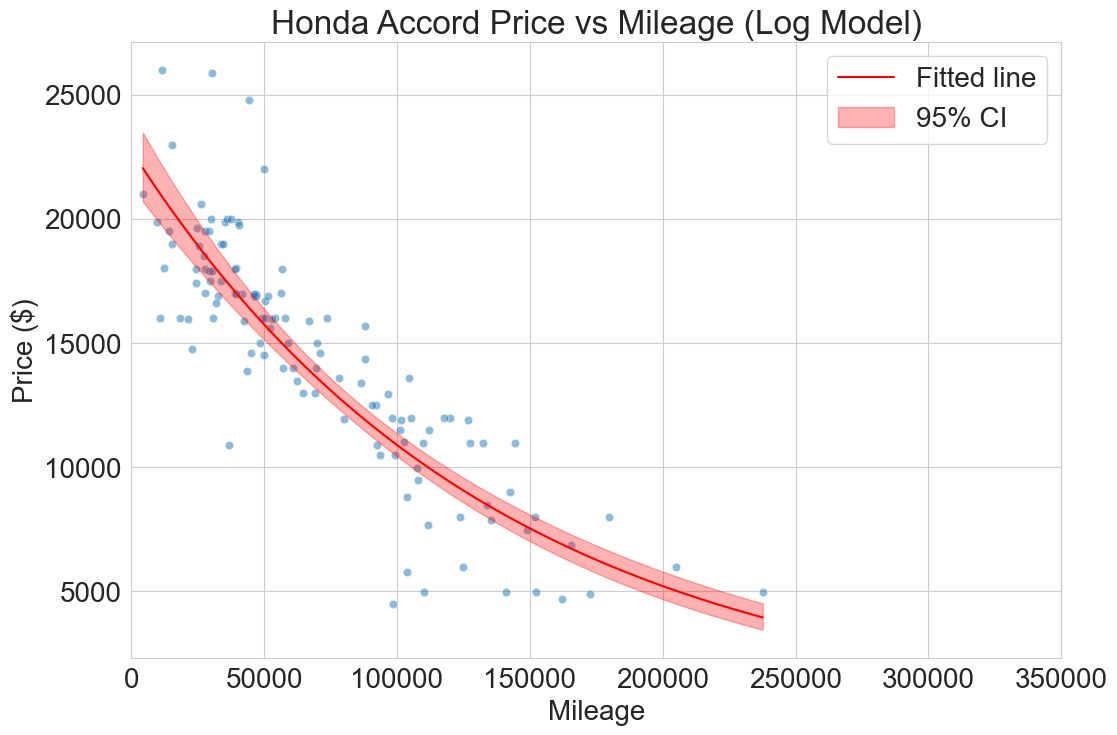

In [9]:
# Plot the log-transformed model
sns.scatterplot(data=accords, x='mileage', y='price', alpha=0.5)

# Generate predictions
mileage_range = np.linspace(accords['mileage'].min(), accords['mileage'].max(), 100)
X_pred = sm.add_constant(mileage_range)
pred_log = model_log.get_prediction(X_pred)
pred_mean = np.exp(pred_log.predicted_mean)
pred_ci = np.exp(pred_log.conf_int())

plt.plot(mileage_range, pred_mean, color='red', label='Fitted line')
plt.fill_between(mileage_range, pred_ci[:, 0], pred_ci[:, 1], alpha=0.3, color='red', label='95% CI')
plt.title('Honda Accord Price vs Mileage (Log Model)')
plt.xlabel('Mileage')
plt.ylabel('Price ($)')
plt.xlim(0, 350000)
plt.legend()
plt.show()

## 🚀 Exercise 7

Identify and interpret the following components of your log-transformed model:

- $\exp(\hat{\beta}_0)$
- $\exp(\hat{\beta}_1)$
- $\text{R}^2$

Interpret $\exp(\hat{\beta}_1)$ in terms of **an increase in 10,000 miles**, not an increase of 1 mile.

Tip: Use the `coef` function to extract the model coefficients from your model object.

In [10]:
# Print coefficients
print(model_log.summary())

# Extract coefficients
beta0 = model_log.params['const']
beta1 = model_log.params['mileage']
r2 = model_log.rsquared

print(f"\nexp(β0): {np.exp(beta0):.0f}")
print(f"exp(β1): {np.exp(beta1):.4f}")
print(f"R²: {r2:.3f}")

# For 10,000 miles: (exp(β1))^10000
multiplier_10k = np.exp(beta1 * 10000)
print(f"Multiplier for 10,000 miles: {multiplier_10k:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     356.2
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           1.01e-37
Time:                        10:17:33   Log-Likelihood:                 23.725
No. Observations:                 122   AIC:                            -43.45
Df Residuals:                     120   BIC:                            -37.84
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0325      0.033    302.631      0.0

---

The value of $\exp(\hat{\beta}_0)$ with units: 22754 dollars

Interpretation: The predicted price of a Honda Accord with 0 miles is $22,754.

---

The value of $\exp(\hat{\beta}_1)$ with units: 1.0000 (dimensionless)

Interpretation: For each additional mile, the price is multiplied by 1.0000, meaning a 0% change per mile.

---

The value of $\text{R}^2$ with units: 0.748

Interpretation: 74.8% of the variation in the log of Honda Accord prices is explained by mileage.

---

For an increase of 10,000 miles, the price is multiplied by 0.929, meaning the price decreases by about 7.1% for every additional 10,000 miles.

---

## 🚀 Exercise 8

Refine your regression model from Exercise 5 to include the model year as an additional predictor. You should still use just the Honda Accord data.

In one sentence, compare the $R^2$ of the revised regression model to your model from Exercise 5.

In [11]:
# Add year to the log model
X_year = sm.add_constant(accords[['mileage', 'year']])
model_year = sm.OLS(y_log, X_year).fit()
print(model_year.summary())

print(f"\nR² for model with year: {model_year.rsquared:.3f}")
print(f"Previous R² (without year): {model_log.rsquared:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     373.8
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           4.93e-52
Time:                        10:17:43   Log-Likelihood:                 60.761
No. Observations:                 122   AIC:                            -115.5
Df Residuals:                     119   BIC:                            -107.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -122.9795     13.342     -9.217      0.0

---

The R² of the revised model (0.863) is higher than the model from Exercise 5 (0.748), indicating that adding the model year improves the model's ability to explain the variation in Honda Accord prices.

---

## 🚀 Exercise 9

Fit the model from Exercise 8
**the entire dataset**, not just the Honda Accords.
You'll notice that the new $R^2$ is lower than the $R^2$ from the model from Exercise 8.
In one sentence, what is the likely reason for this difference?

In [12]:
# Fit model on entire dataset
cars_clean = cars.dropna(subset=['price', 'mileage', 'year'])
X_full = sm.add_constant(cars_clean[['mileage', 'year']])
y_full_log = np.log(cars_clean['price'])
model_full = sm.OLS(y_full_log, X_full).fit()
print(model_full.summary())

print(f"\nR² for full dataset model: {model_full.rsquared:.3f}")
print(f"R² for Accords only: {model_year.rsquared:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     1208.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          1.13e-295
Time:                        10:17:53   Log-Likelihood:                -208.30
No. Observations:                1286   AIC:                             422.6
Df Residuals:                    1283   BIC:                             438.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -147.3908      9.008    -16.363      0.0

---

The R² is lower (0.653 vs 0.863) because the model now includes cars of different makes and models, which have different baseline prices and depreciation patterns, adding more unexplained variation.

---

## 🚀 Exercise 10

Update the model from Exercise 9 to address the likely reason for the much smaller $R^2$.

- In this new model, what's the interpretation of the exponentiated intercept term?

- What is one change you could make to your model to make the intercept term more interpretable?

Answer in no more than three sentences.

In [13]:
# Update model to include make as dummies
X_full_make = pd.get_dummies(cars_clean[['mileage', 'year', 'make']], drop_first=True)
X_full_make = sm.add_constant(X_full_make.astype(float))
model_make = sm.OLS(y_full_log, X_full_make).fit()
print(model_make.summary())

print(f"\nR² with make: {model_make.rsquared:.3f}")
print(f"Previous R²: {model_full.rsquared:.3f}")

# Exp intercept
print(f"exp(intercept): {np.exp(model_make.params['const']):.2f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     1244.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:18:08   Log-Likelihood:                 576.90
No. Observations:                1286   AIC:                            -1134.
Df Residuals:                    1276   BIC:                            -1082.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -162.2522      5.007    -

---

In this new model, the exponentiated intercept term represents the predicted price for a reference make (Acura, since drop_first=True) car with 0 miles in year 0, which is essentially zero and not meaningful.

One change you could make to the model to make the intercept term more interpretable is to center the year variable, e.g., use year - 2000, so the intercept represents the price for a car from the year 2000.

---

# 🚀 Exercise 11

Implement your suggested change from Exercise 10, and print the resulting model output.

What's the interpretation of the exponentiated intercept term? Answer in one sentence.

What's the interpretation of the term for the model year? Answer in one sentence.

In [14]:
# Implement centering year
cars_clean['year_centered'] = cars_clean['year'] - 2000
X_centered = pd.get_dummies(cars_clean[['mileage', 'year_centered', 'make']], drop_first=True)
X_centered = sm.add_constant(X_centered.astype(float))
model_centered = sm.OLS(y_full_log, X_centered).fit()
print(model_centered.summary())

print(f"\nexp(intercept): {np.exp(model_centered.params['const']):.2f}")

# Interpretation of year coef
year_coef = model_centered.params['year_centered']
print(f"Year coefficient: {year_coef:.4f}")
print(f"exp(year coef): {np.exp(year_coef):.4f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     1244.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:18:17   Log-Likelihood:                 576.90
No. Observations:                1286   AIC:                            -1134.
Df Residuals:                    1276   BIC:                            -1082.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.3607      0.036    2

---

The exponentiated intercept term represents the predicted price for a reference make (Acura) car with 0 miles in the year 2000.

The term for the model year indicates that for each additional year, the price is multiplied by 1.09, meaning prices increase by about 9% per year on average.

---